# Plot Hovmöller Diagrams for SIC, SST, SSS

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46867")
client

<Client: 'tcp://127.0.0.1:46867' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

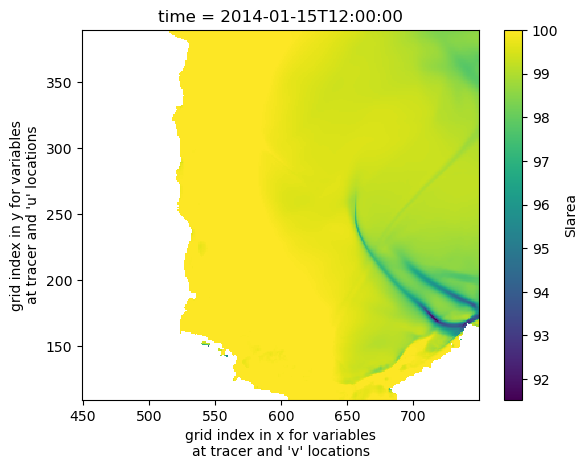

In [24]:
ice_beaufort.isel(time=0).plot();

### Identify line along 71N to plot

In [73]:
# pull out profiles along 71N
grid_beaufort = HH_grid.isel(i=slice(450,750),j=slice(110,390)).Depth
i_idx_71N = []
for jj in grid_beaufort.j.values:
    line_lats = grid_beaufort.sel(j=jj).YC.values
    lat_idx = np.argmin(abs(line_lats-71))
    i_idx_71N.append(lat_idx)

i_71N_da = np.array(grid_beaufort.isel(i=i_idx_71N).i.values)
j_71N_da = grid_beaufort.j.values

In [74]:
# pull out profiles along 500 m isobath
depth_beaufort = HH_grid.isel(i=slice(450,645),j=slice(149,390)).Depth
i_idx_500isobath = []
for jj in depth_beaufort.j.values:
    line_depths = depth_beaufort.sel(j=jj).values
    isobath_idx = np.argmin(abs(line_depths-500))
    i_idx_500isobath.append(isobath_idx)

i_idx_500isobath_da = np.array(depth_beaufort.isel(i=i_idx_500isobath).i.values)
j_idx_500isobath_da = depth_beaufort.j.values

In [75]:
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth

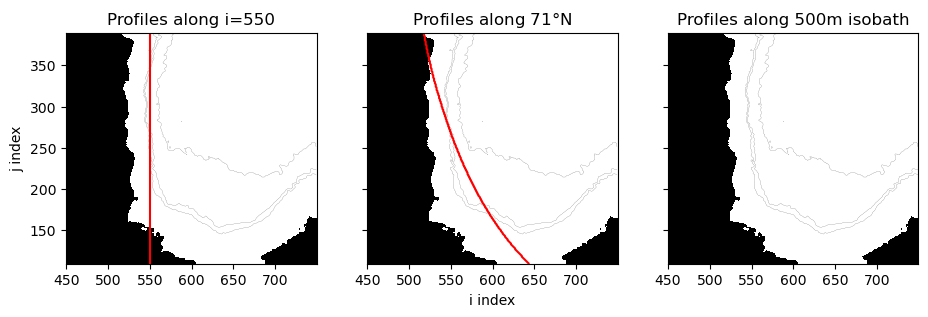

In [30]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[11,3],sharey=True)

for ax in (ax1,ax2,ax3):
    HH_land_beaufort.plot(ax=ax,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
    bathy_beaufort.plot.contour(ax=ax, colors='k', linewidths=0.1, levels=[500,1000,3000])
    ax.set_xlabel('')
    ax.set_ylabel('')

ax1.axvline(x=550,c='red')
ax2.plot(i_71N_da, j_71N_da, color='r')
# ax3.plot(i_idx_500isobath_da, j_idx_500isobath_da, color='r')

ax1.set_ylabel('j index')
ax2.set_xlabel('i index')
ax1.set_title(f'Profiles along i=550');
ax2.set_title(f'Profiles along 71$\degree$N');
ax3.set_title(f'Profiles along 500m isobath');

## Plot Hovmöller Diagrams

### SIC

#### Using matrix multiplication

In [77]:
# pull out profiles along 71N
grid_beaufort = HH_grid.isel(i=slice(450,750),j=slice(110,390)).Depth
i_idx_71N = []
for jj in grid_beaufort.j.values:
    line_lats = grid_beaufort.sel(j=jj).YC.values
    lat_idx = np.argmin(abs(line_lats-70.5))
    i_idx_71N.append(lat_idx)

i_71N_da = np.array(i_idx_71N)
j_71N_da = np.arange(len(grid_beaufort.j.values))

In [78]:
# make matrix of profiles along 71N

# create a boolean mask with all False values
mask_71N = np.zeros(grid_beaufort.shape, dtype=bool)

# set True where needed
mask_71N[j_71N_da, i_71N_da] = True

# check shape
print(mask_71N.shape)

(280, 300)


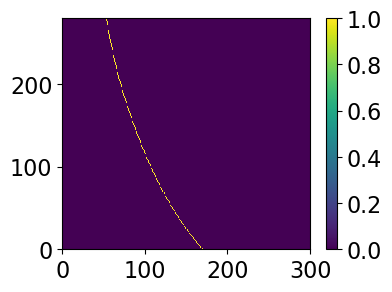

In [79]:
# check matrix
plt.figure(figsize=(4, 3))
plt.pcolormesh(mask_71N)
plt.colorbar();

In [80]:
ice_beaufort_2019 = ice_beaufort.sel(time=slice('2019-10-01','2019-12-31'))

In [81]:
# apply the mask to ice_beaufort_2019 with shape (92, 280, 300)
ice_71N_2019 = ice_beaufort_2019.values[:, mask_71N]

In [82]:
ice_71N_2019.shape

(92, 280)

In [83]:
# Create a date range
date_range = pd.date_range(start='2023-09-01', end='2023-12-31', freq='D')

# Format dates as strings (e.g., 'Sep 15', 'Sep 16', ...)
formatted_dates = date_range.strftime('%b %d').tolist()

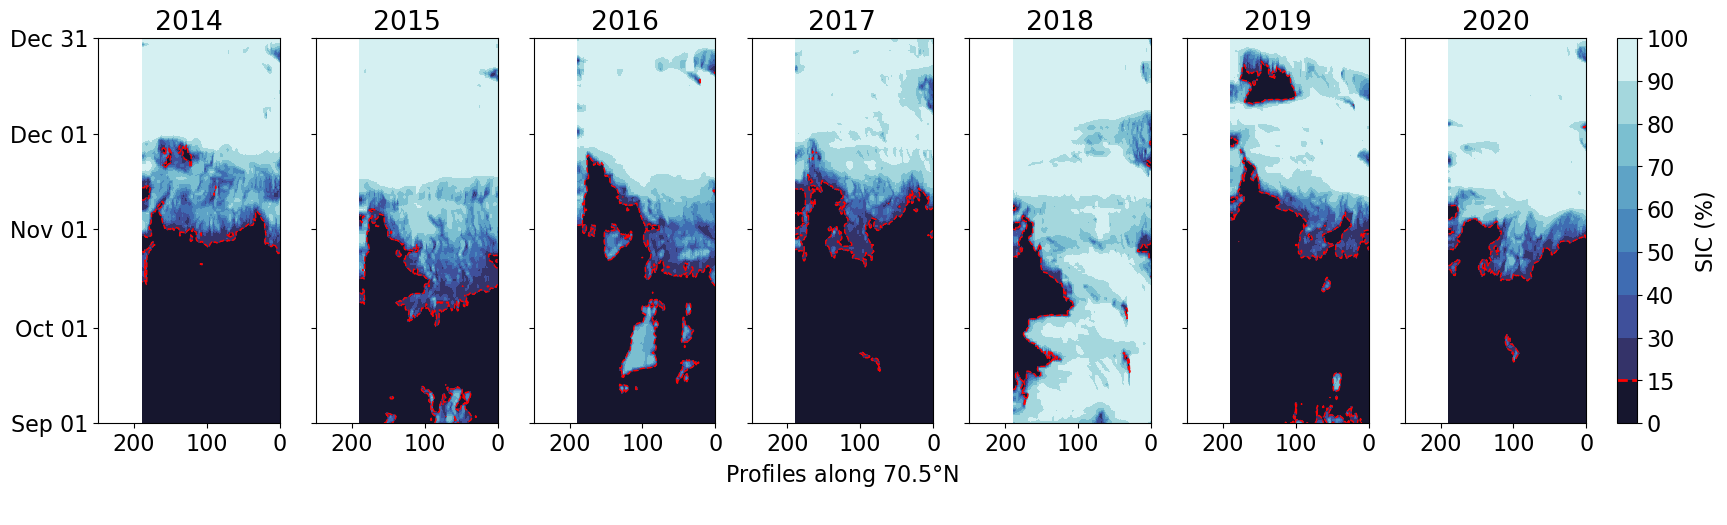

In [84]:
years = np.arange(2014,2021)
plt.rcParams['font.size'] = 16

fig, axs = plt.subplots(1,7,figsize=[20,5],sharey=True,sharex=True)
for year,ax in zip(years,axs):
    ice_beaufort_yr = ice_beaufort.sel(time=slice(f'{year}-09-01',f'{year}-12-31'))
    ice_71N_yr = ice_beaufort_yr.values[:, mask_71N]
    
    cbar_ice = ax.contourf(ice_71N_yr,vmin=0,vmax=100,cmap=cmocean.cm.ice,levels=[0,15,30,40,50,60,70,80,90,100])
    ax.contour(ice_71N_yr,colors='r',linestyles='dashed',linewidths=1,levels=[15])
    # plt.pcolormesh(ice_71N_2019,cmap='Blues_r')
    ax.set_title(year)
    ax.set_xticks([0,100,200])
    ax.set_xlim(249,0);
    
# plt.suptitle("71$\degree$N\n");
axs[0].set_yticks([0,30,61,91,121])
axs[0].set_yticklabels([formatted_dates[0],formatted_dates[30],formatted_dates[61],formatted_dates[91],formatted_dates[121]])
axs[3].set_xlabel("Profiles along 71$\degree$N\n")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_ice, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.set_ylabel('SIC (%)')
cbar.ax.axhline(y=15, color='r', linestyle='dashed', linewidth=2);

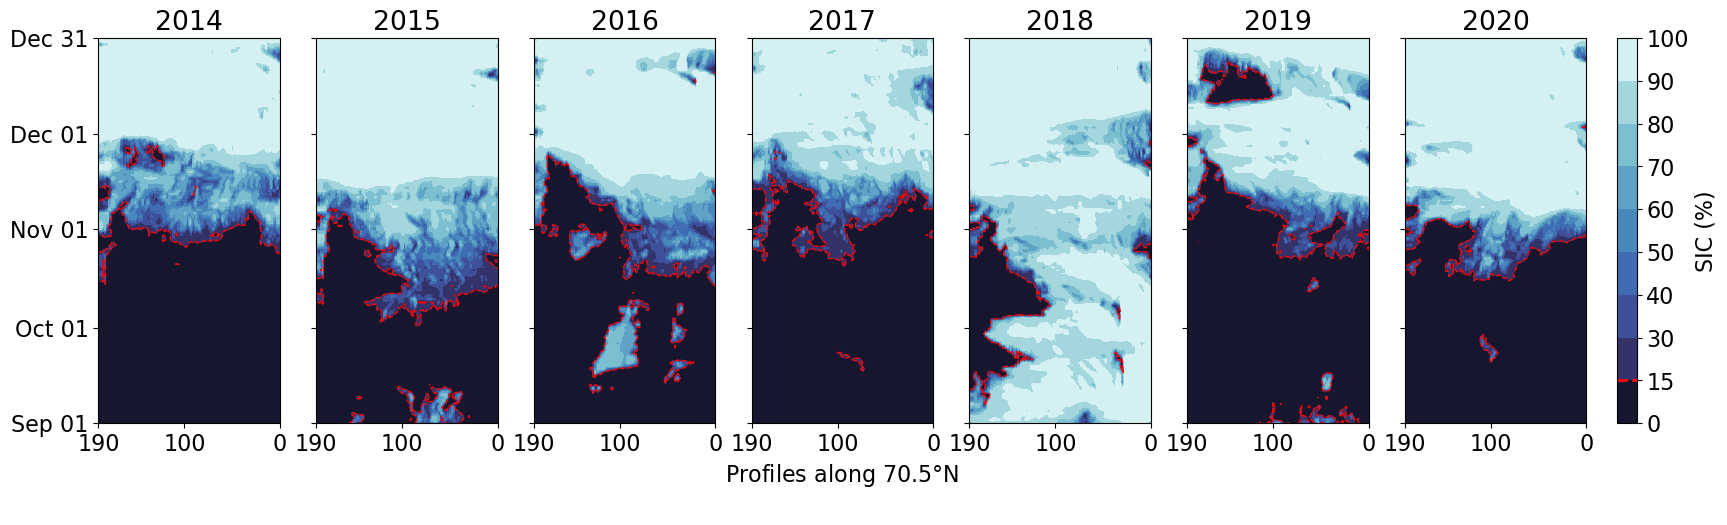

In [91]:
years = np.arange(2014,2021)
plt.rcParams['font.size'] = 16

fig, axs = plt.subplots(1,7,figsize=[20,5],sharey=True,sharex=True)
for year,ax in zip(years,axs):
    ice_beaufort_yr = ice_beaufort.sel(time=slice(f'{year}-09-01',f'{year}-12-31'))
    ice_71N_yr = ice_beaufort_yr.values[:, mask_71N]
    
    cbar_ice = ax.contourf(ice_71N_yr,vmin=0,vmax=100,cmap=cmocean.cm.ice,levels=[0,15,30,40,50,60,70,80,90,100])
    ax.contour(ice_71N_yr,colors='r',linestyles='dashed',linewidths=1,levels=[15])
    # plt.pcolormesh(ice_71N_2019,cmap='Blues_r')
    ax.set_title(year)
    ax.set_xticks([0,100,190])
    ax.set_xlim(190,0);
    
# plt.suptitle("71$\degree$N\n");
axs[0].set_yticks([0,30,61,91,121])
axs[0].set_yticklabels([formatted_dates[0],formatted_dates[30],formatted_dates[61],formatted_dates[91],formatted_dates[121]])
axs[3].set_xlabel("Profiles along 70.5$\degree$N\n")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_ice, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.set_ylabel('SIC (%)')
cbar.ax.axhline(y=15, color='r', linestyle='dashed', linewidth=2);

In [58]:
# Create a date range
date_range = pd.date_range(start='2023-06-01', end='2023-12-31', freq='D')

# Format dates as strings (e.g., 'Sep 15', 'Sep 16', ...)
formatted_dates = date_range.strftime('%b %d').tolist()

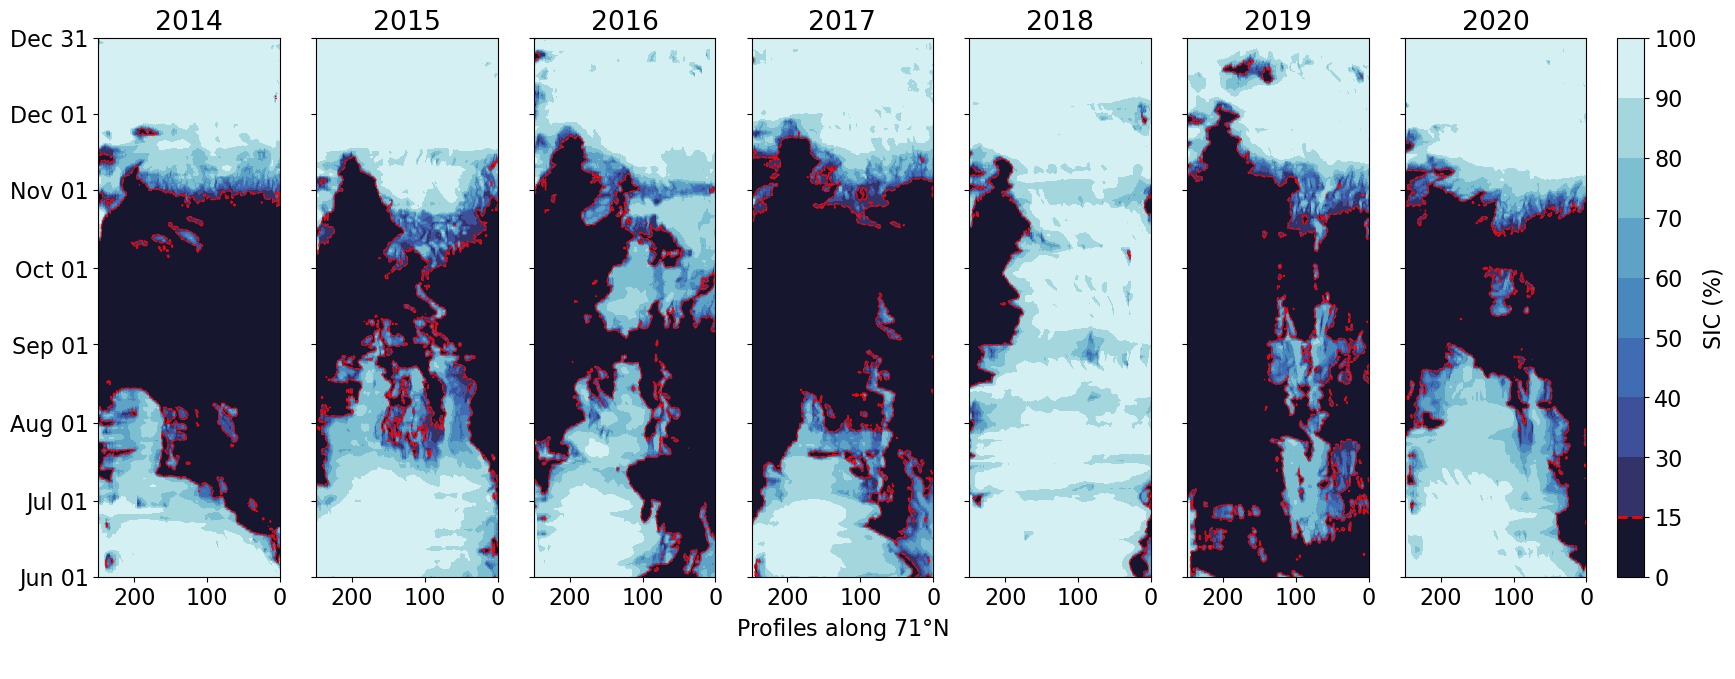

In [62]:
years = np.arange(2014,2021)
plt.rcParams['font.size'] = 16
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]

fig, axs = plt.subplots(1,7,figsize=[20,7],sharey=True,sharex=True)
for year,ax in zip(years,axs):
    ice_beaufort_yr = ice_beaufort.sel(time=slice(f'{year}-06-01',f'{year}-12-31'))
    ice_71N_yr = ice_beaufort_yr.values[:, mask_71N]
    
    cbar_ice = ax.contourf(ice_71N_yr,vmin=0,vmax=100,cmap=cmocean.cm.ice,levels=levels)
    ax.contour(ice_71N_yr,colors='r',linestyles='dashed',linewidths=1,levels=[15])
    # plt.pcolormesh(ice_71N_2019,cmap='Blues_r')
    ax.set_title(year)
    ax.set_xticks([0,100,200])
    ax.set_xlim(249,0);
    
# plt.suptitle("71$\degree$N\n");
axs[0].set_yticks([0,30,61,92,122,153,183,213])
axs[0].set_yticklabels([formatted_dates[0],formatted_dates[30],formatted_dates[61],formatted_dates[92],formatted_dates[122],formatted_dates[153],formatted_dates[183],formatted_dates[213]])
axs[3].set_xlabel("Profiles along 71$\degree$N\n")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_ice, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.set_ylabel('SIC (%)')
cbar.ax.axhline(y=15, color='r', linestyle='dashed', linewidth=2);

#### Using sel

For 2019 only

In [33]:
ice_beaufort_2019 = ice_beaufort.sel(time=slice('2019-10-01','2019-12-31'))

In [34]:
# loop through all i,j pairs and create a new dataset for profiles along 71N
for i in range(len(i_71N_da)):
    if i == 0:
        profiles_71N = ice_beaufort_2019.sel(i=i_71N_da[i],j=j_71N_da[i])
        profiles_71N.expand_dims(profile=[1])
    else:
        profiles_tmp = ice_beaufort_2019.sel(i=i_71N_da[i],j=j_71N_da[i])
        profiles_71N = xr.concat([profiles_71N, profiles_tmp], dim='profile')

All days

In [31]:
# loop through all i,j pairs and create a new dataset for profiles along 71N
for i in range(len(i_71N_da)):
    if i == 0:
        profiles_71N = ice_beaufort.sel(i=i_71N_da[i],j=j_71N_da[i])
        profiles_71N.expand_dims(profile=[1])
    else:
        profiles_tmp = ice_beaufort.sel(i=i_71N_da[i],j=j_71N_da[i])
        profiles_71N = xr.concat([profiles_71N, profiles_tmp], dim='profile')

Isobath example

In [14]:
# loop through all i,j pairs and create a new dataset for profiles along 500 m isobath
for i in range(len(i_idx_500isobath_da)):
    if i == 0:
        profiles_isobath = ice_beaufort.sel(i=i_idx_500isobath_da[i],j=j_idx_500isobath_da[i])
        profiles_isobath.expand_dims(profile=[1])
    else:
        profiles_tmp = ice_beaufort.sel(i=i_idx_500isobath_da[i],j=j_idx_500isobath_da[i])
        profiles_isobath = xr.concat([profiles_isobath, profiles_tmp], dim='profile')

In [70]:
# convert time to Day of Year (DOY)
doy = profile_71N['time'].dt.dayofyear

# group by DOY and compute the mean across years
ice_conc_doy_mean = profiles_71N.groupby(doy).mean(dim='time')

Time taken: 320.0 seconds


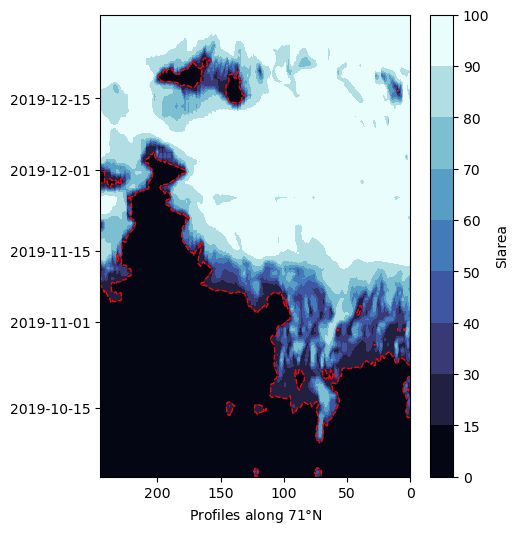

In [24]:
start = time.time()
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]
profiles_71N_2019 = profiles_71N.sel(time=slice('2019-10-01','2019-12-31'))
profiles_71N_2019.plot.contourf(y='time',vmin=0,vmax=100,levels=levels,cmap=cmocean.cm.ice,figsize=(5, 6))

# Plot contour lines for sea ice concentration
profiles_71N_2019.plot.contour(y='time',levels=[15], colors='r', linestyles='dashed', linewidths=1)

plt.xlim(245,0);
plt.xlabel('Profiles along 71$\degree$N')
plt.ylabel('')
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 256.0 seconds


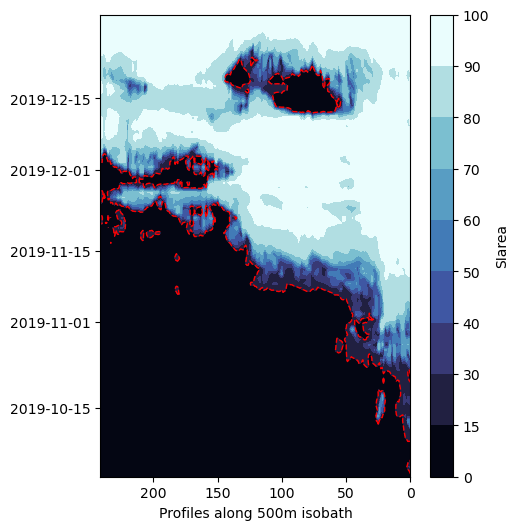

In [15]:
start = time.time()
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]
profiles_isobath_2019 = profiles_isobath.sel(time=slice('2019-10-01','2019-12-31'))
profiles_isobath_2019.plot.contourf(y='time',vmin=0,vmax=100,levels=levels,cmap=cmocean.cm.ice,figsize=(5, 6))

# Plot contour lines for sea ice concentration
profiles_isobath_2019.plot.contour(y='time',levels=[15], colors='r', linestyles='dashed', linewidths=1)

plt.xlim(241,0);
plt.xlabel('Profiles along 500m isobath')
plt.ylabel('')
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

In [ ]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Define contour levels
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]

# Plot Hovmöller Diagram
cbar_plot = ice_conc_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap=cmocean.cm.ice, levels=levels, add_colorbar=False
)

# Plot contour lines for sea ice concentration
ice_conc_doy_mean.plot.contour(
    ax=ax, x='j', y='dayofyear', levels=[15], colors='r', linestyles='dashed', linewidths=1
)

# Plot contour line for 80% sea ice concentration
ice_conc_doy_mean.plot.contour(
    ax=ax, x='j', y='dayofyear', levels=[80], colors='r', linestyles='solid', linewidths=1
)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean Sea Ice Cover along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SIC (%)")

# Add a red marker at 80% on the colorbar
cbar.ax.axvline(x=15, color='r', linewidth=1.5, linestyle='dashed')
cbar.ax.axvline(x=80, color='r', linewidth=1)

plt.show()

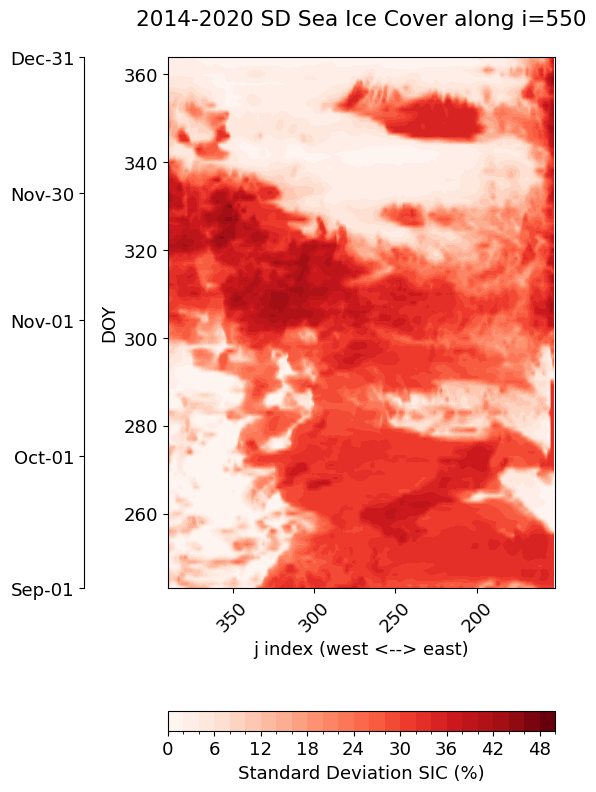

In [24]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Define contour levels
levels = np.arange(0,52,2)

# Plot Hovmöller Diagram
cbar_plot = ice_conc_doy_std.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap='Reds', levels=levels, add_colorbar=False
)

# # Plot contour line for 80% sea ice concentration
# contour_80 = ice_conc_doy_mean.plot.contour(
#     ax=ax, x='j', y='dayofyear', levels=[15], colors='r', linewidths=2
# )

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 SD Sea Ice Cover along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("Standard Deviation SIC (%)")

# Add a red marker at 80% on the colorbar
# cbar.ax.axvline(x=80, color='r', linewidth=2)

plt.show()

### SST

In [172]:
sst_select = theta_da.isel(i=550,j=slice(150,390),k=0)

In [174]:
# convert time to Day of Year (DOY)
doy = sst_select['time'].dt.dayofyear

# group by DOY and compute the mean across years
sst_doy_mean = sst_select.groupby(doy).mean(dim='time')

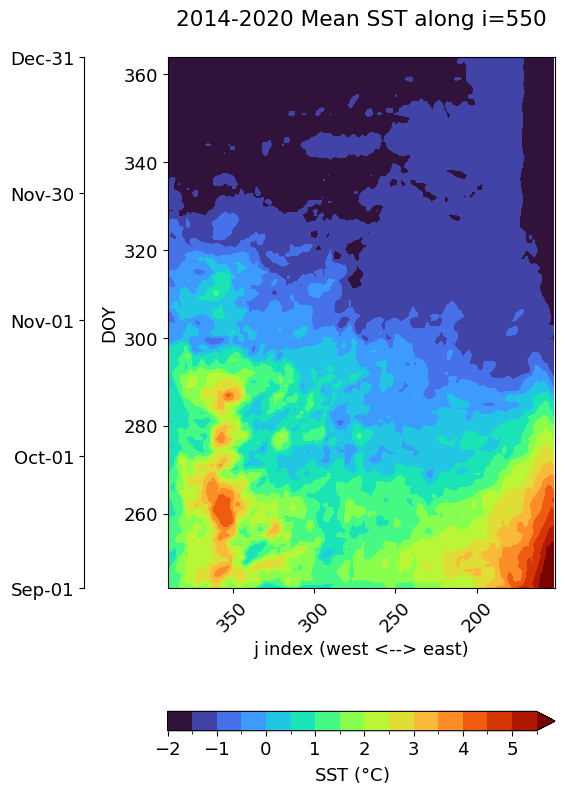

In [183]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Plot Hovmöller Diagram
levels=np.arange(-2, 6, 0.5)
cbar_plot = sst_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap='turbo', levels=levels, add_colorbar=False)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean SST along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SST ($\degree$C)")

plt.show()

### SSS

In [184]:
sss_select = salt_da.isel(i=550,j=slice(150,390),k=0)

In [185]:
# convert time to Day of Year (DOY)
doy = sss_select['time'].dt.dayofyear

# group by DOY and compute the mean across years
sss_doy_mean = sss_select.groupby(doy).mean(dim='time')

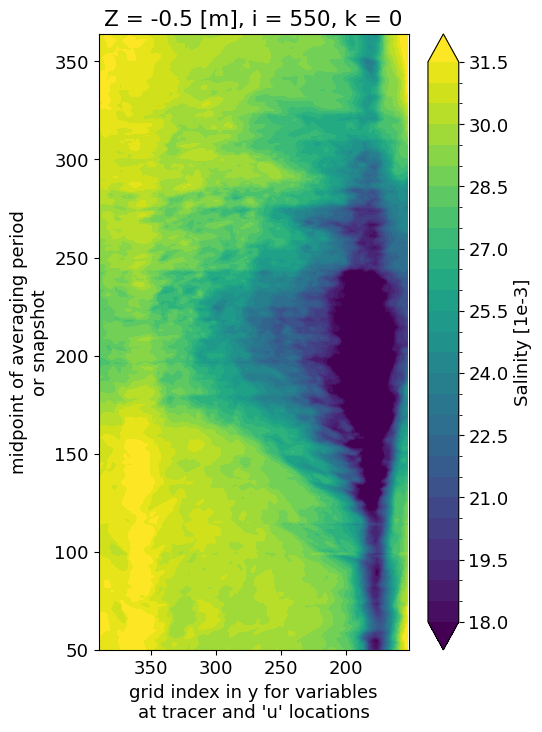

In [188]:
# Define contour levels
levels = np.arange(18, 32, 0.5)  # Ensure it fully covers the data range

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 8))

# Plot Hovmöller Diagram using xarray's contourf function
sss_doy_mean.plot.contourf(ax=ax, x='j', y='dayofyear', levels=levels, cmap='viridis')
ax.set_xlim(390, 152)
ax.set_ylim(50, 364);

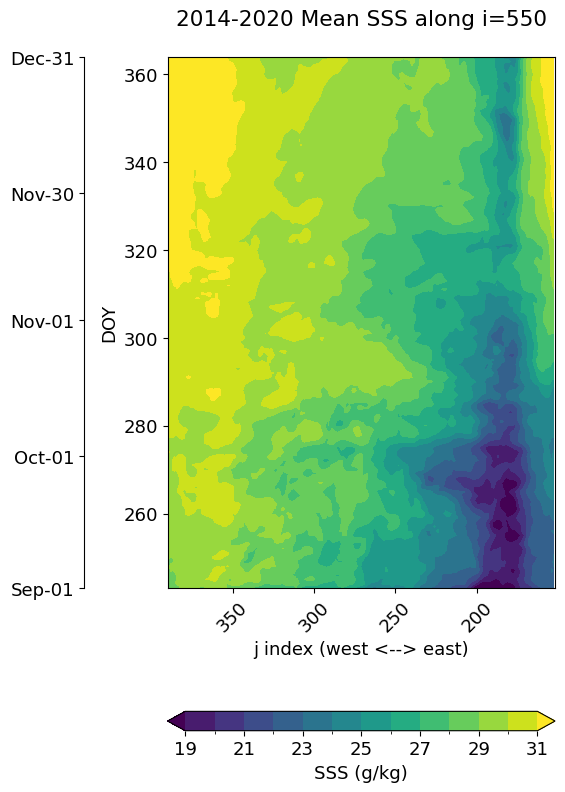

In [189]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Plot Hovmöller Diagram
levels = np.arange(19, 32, 1)
cbar_plot = sss_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap='viridis', levels=levels, add_colorbar=False)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean SSS along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SSS (g/kg)")

plt.show()